In [153]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader 
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom

In [210]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [211]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [212]:
protons = protons[(protons['height'] < 100) & (protons['width'] < 400)]
deuterons = deuterons[(deuterons['height'] < 100) & (deuterons['width'] < 400)]

In [213]:
protons.shape, deuterons.shape

((6291, 37), (5115, 37))

In [214]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(399, 99, 399, 99)

In [410]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

<Axes: >

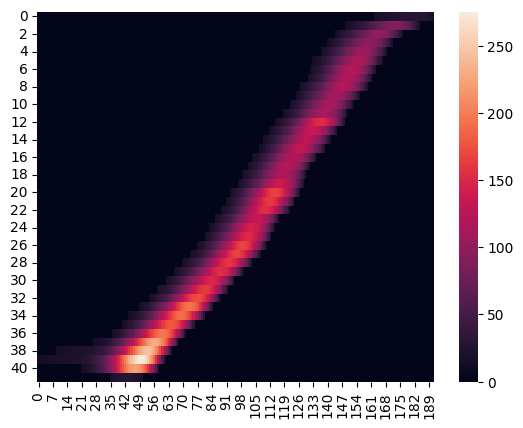

In [411]:
i = 14
sns.heatmap(protons['image_intensity'].iloc[i])

In [412]:
int(np.argmax(protons['image_intensity'].iloc[i][0]))

180

In [413]:
pv = []                                                 # vertex
pe = []                                                 # end   
for idx, row in protons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    pv.append(vertex)
    pe.append(end)

pv = np.array(pv)
pe = np.array(pe)

dv = []                                                 # vertex
de = []                                                 # end   
for idx, row in deuterons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    dv.append(vertex)
    de.append(end)

np.int64(-348)

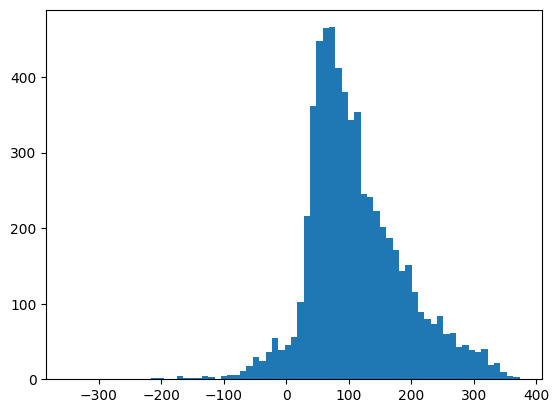

In [414]:
plt.hist(pv - pe, bins='auto')
min(pv-pe)

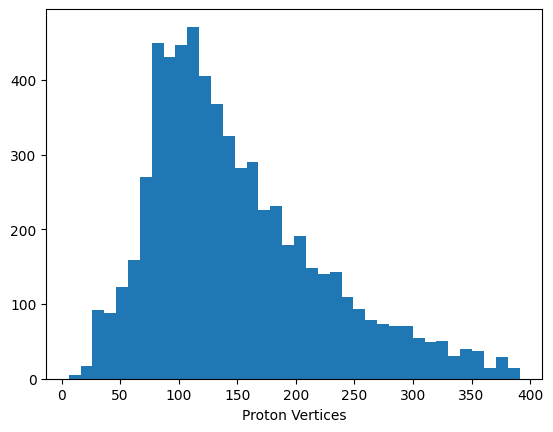

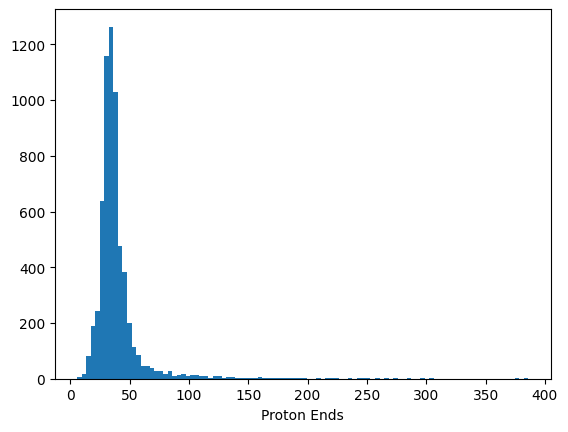

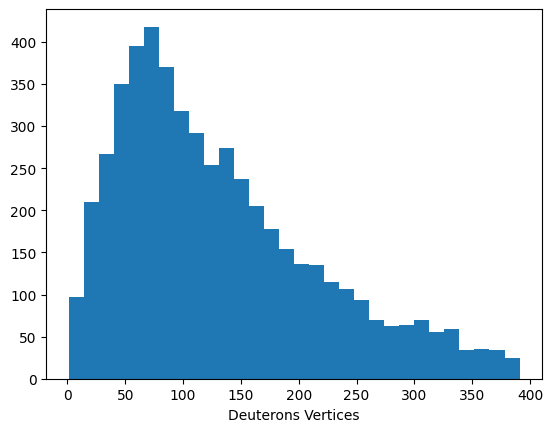

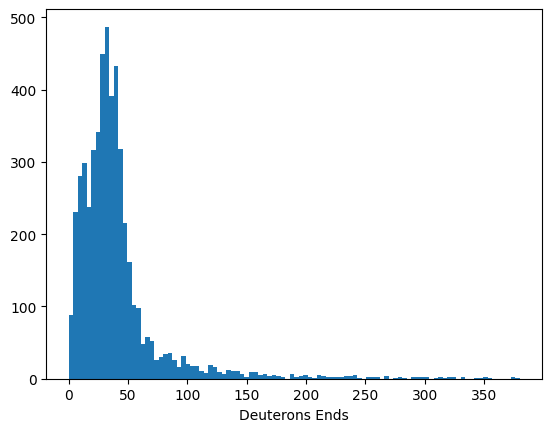

In [415]:
plt.hist(pv, bins='auto'); plt.xlabel('Proton Vertices'); plt.show()
plt.hist(pe, bins=100); plt.xlabel('Proton Ends'); plt.show()
plt.hist(dv, bins='auto'); plt.xlabel('Deuterons Vertices'); plt.show()
plt.hist(de, bins=100); plt.xlabel('Deuterons Ends'); plt.show()

<Axes: >

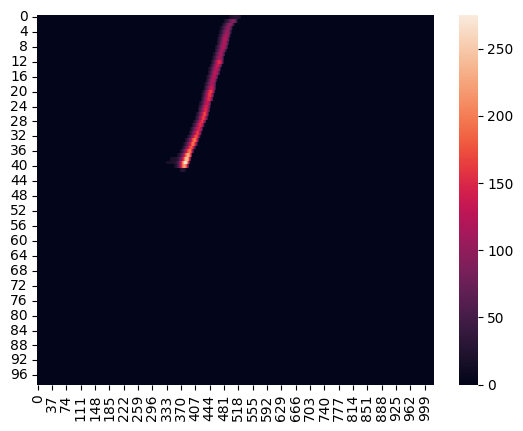

In [416]:
pad = pad_image(protons['image_intensity'].iloc[i])
sns.heatmap(pad)

In [417]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [418]:
p = [] 
d = []

for idx, row in protons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    p.append(padded)

for idx, row in deuterons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    d.append(padded)

p = np.array(p)
d = np.array(d)

p_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p])
d_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d])

In [420]:
imgpv = []                                                 # vertex
imgpe = []                                                 # end   
for img in p_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgpv.append(vertex)
    imgpe.append(end)

imgdv = []                                                 # vertex
imgde = []                                                 # end   
for img in d_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgdv.append(vertex)
    imgde.append(end)

0


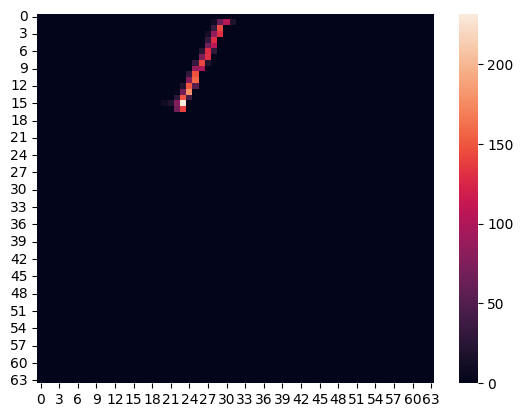

In [436]:
i = 2
sns.heatmap(p_d[i]); print(np.argmax(p_d[i][0]))

<Axes: >

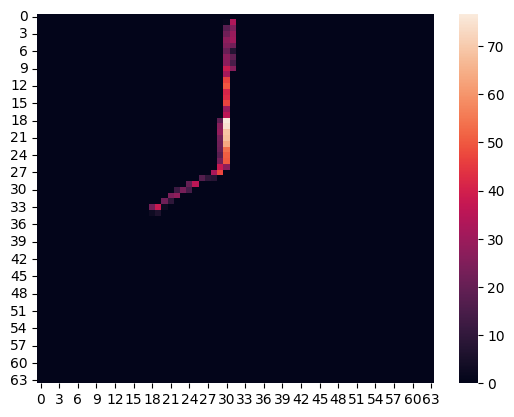

In [438]:
sns.heatmap(d_d[3])

In [439]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [443]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CAE(input_hw=(64, 64), latent=16).to(device)
optim  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

In [444]:
X = torch.tensor(p_d, dtype=torch.float32).to(device)  # shape (N, H, W)
train_loader = torch.utils.data.DataLoader(X, batch_size=32, shuffle=True)
epochs = 15

In [447]:
for epoch in range(epochs):
    model.train()
    for xb in train_loader:
        xb = xb.to(device)
        optim.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, xb)
        loss.backward()
        optim.step()
    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 8.0547
Epoch 2: loss = 3.5839
Epoch 3: loss = 4.5386
Epoch 4: loss = 3.1354
Epoch 5: loss = 3.3125
Epoch 6: loss = 3.3544
Epoch 7: loss = 3.9395
Epoch 8: loss = 3.4939
Epoch 9: loss = 3.9582
Epoch 10: loss = 3.3049
Epoch 11: loss = 3.3317
Epoch 12: loss = 2.6886
Epoch 13: loss = 4.9529
Epoch 14: loss = 4.1318
Epoch 15: loss = 4.3790


In [ ]:
# import os
# os.makedirs("/Users/user/data/research/proton-deuteron/models", exist_ok=True)

# # Save checkpoint (best practice: save state_dict + optimizer + meta)
# save_path = "/Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth"
# torch.save({
#     "epoch": epoch + 1,
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optim.state_dict(),
#     "loss": loss.item()
# }, save_path)
# print("Saved checkpoint:", save_path)

# # Optional: save scripted model for inference (CPU-safe)
# scripted_path = "/Users/user/data/research/proton-deuteron/models/anomaly_scripted.pt"
# scripted = torch.jit.script(model.cpu())
# scripted.save(scripted_path)
# print("Saved scripted model:", scripted_path)

Saved checkpoint: /Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth
Saved scripted model: /Users/user/data/research/proton-deuteron/models/anomaly_scripted.pt


In [47]:
ckpt = torch.load("/Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth", map_location="cpu")
model = CAE(input_hw=(240,240), latent=8)
model.load_state_dict(ckpt["model_state_dict"])
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
optim.load_state_dict(ckpt["optimizer_state_dict"])
start_epoch = ckpt.get("epoch", 0)
model.to(device)  # move to desired device
print("Loaded checkpoint, resume at epoch", start_epoch)

Loaded checkpoint, resume at epoch 15


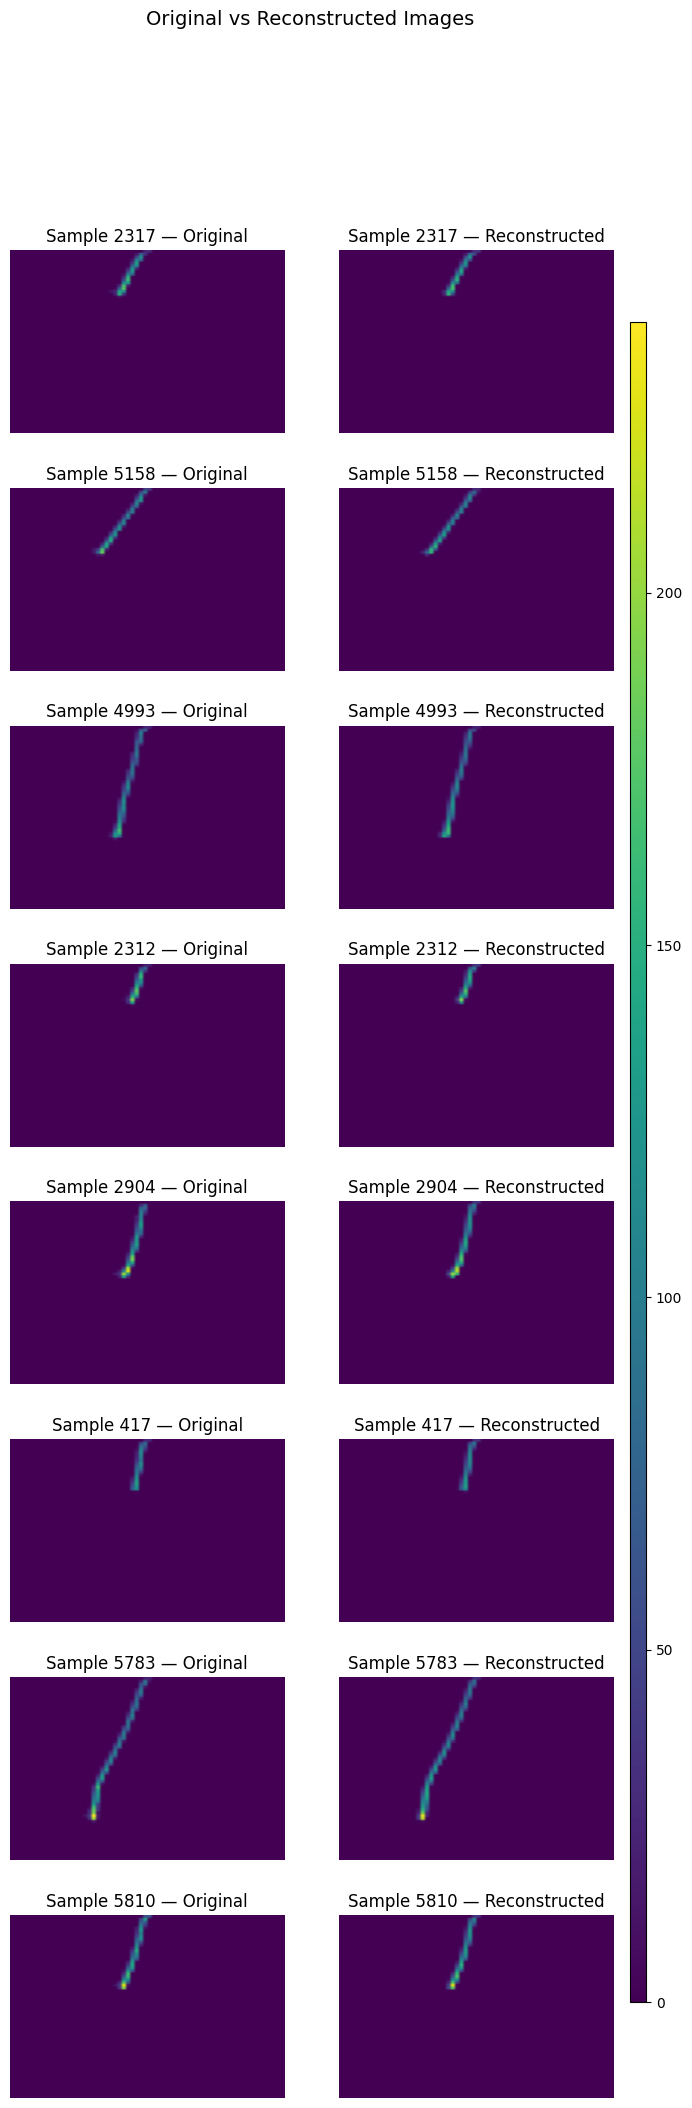

In [448]:
model.eval()

N = 8
X_cpu = X.detach().cpu().numpy()             # full dataset, shape (N_total, H, W)
sample_idx = np.random.choice(len(X_cpu), N, replace=False)
X_sample = X[sample_idx].to(device)          # tensor shape (N, H, W)

# Run through model
with torch.no_grad():
    recons = model(X_sample).cpu().numpy()   # (N, H, W)

# Original images
X_orig = X_sample.cpu().numpy()             # (N, H, W)

# common vmin/vmax for fair comparison
vmin = min(X_orig.min(), recons.min())
vmax = max(X_orig.max(), recons.max())

# Plot side-by-side original / reconstructed for each sample
fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
if N == 1:
    axes = np.expand_dims(axes, 0)

for i in range(N):
    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    im1 = ax1.imshow(X_orig[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax1.set_title(f"Sample {sample_idx[i]} — Original")
    ax1.axis('off')

    im2 = ax2.imshow(recons[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax2.set_title(f"Sample {sample_idx[i]} — Reconstructed")
    ax2.axis('off')

# add single colorbar on the right
fig.subplots_adjust(right=0.88, hspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax)
plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.show()

In [449]:
model.eval()

# choose inference device (fall back to CPU if MPS OOM issues persist)
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

# ensure model is on inference device
model.to(device_inf)

# operate on CPU numpy slices to control memory explicitly
X_np = X.detach().cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   # lower this if you hit MPS OOM
recon_all = np.empty((N, H, W), dtype=np.float32)

# prepare latent storage
latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent: run encoder (expects (B,1,H,W)), flatten and pass fc_enc
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        # free MPS cache if available
        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# compute per-sample MSE (RE) on CPU
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

Inference device: mps
recon_all.shape: (6291, 64, 64)
latent_vectors.shape: (6291, 16)
RE_per_sample.shape: (6291,)


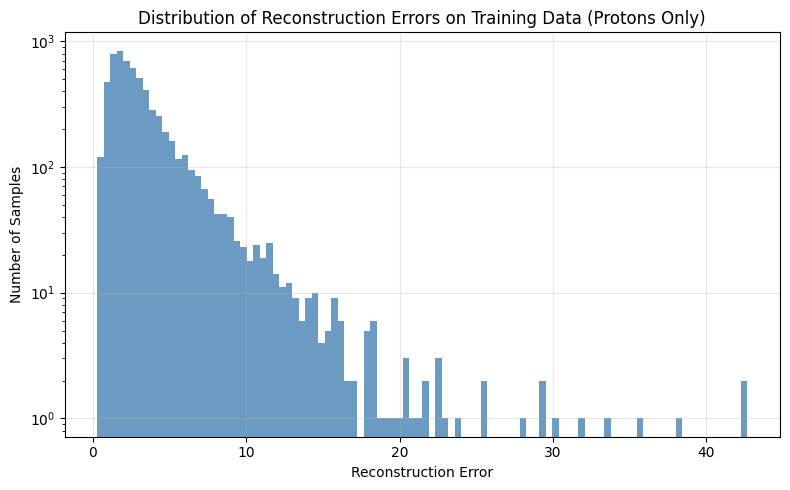

In [457]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Training Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

recon_all.shape: (5115, 64, 64)
latent_vectors.shape: (5115, 16)
RE_per_sample_d.shape: (5115,)


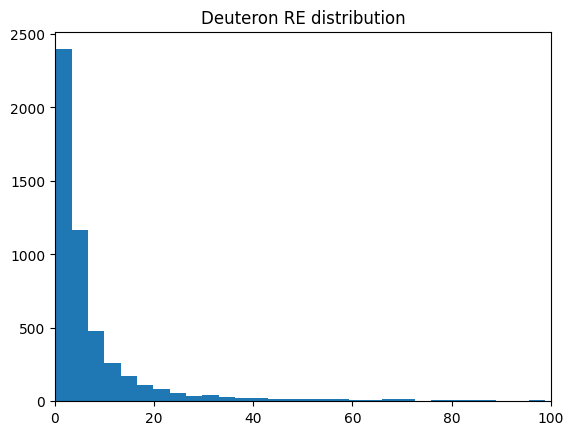

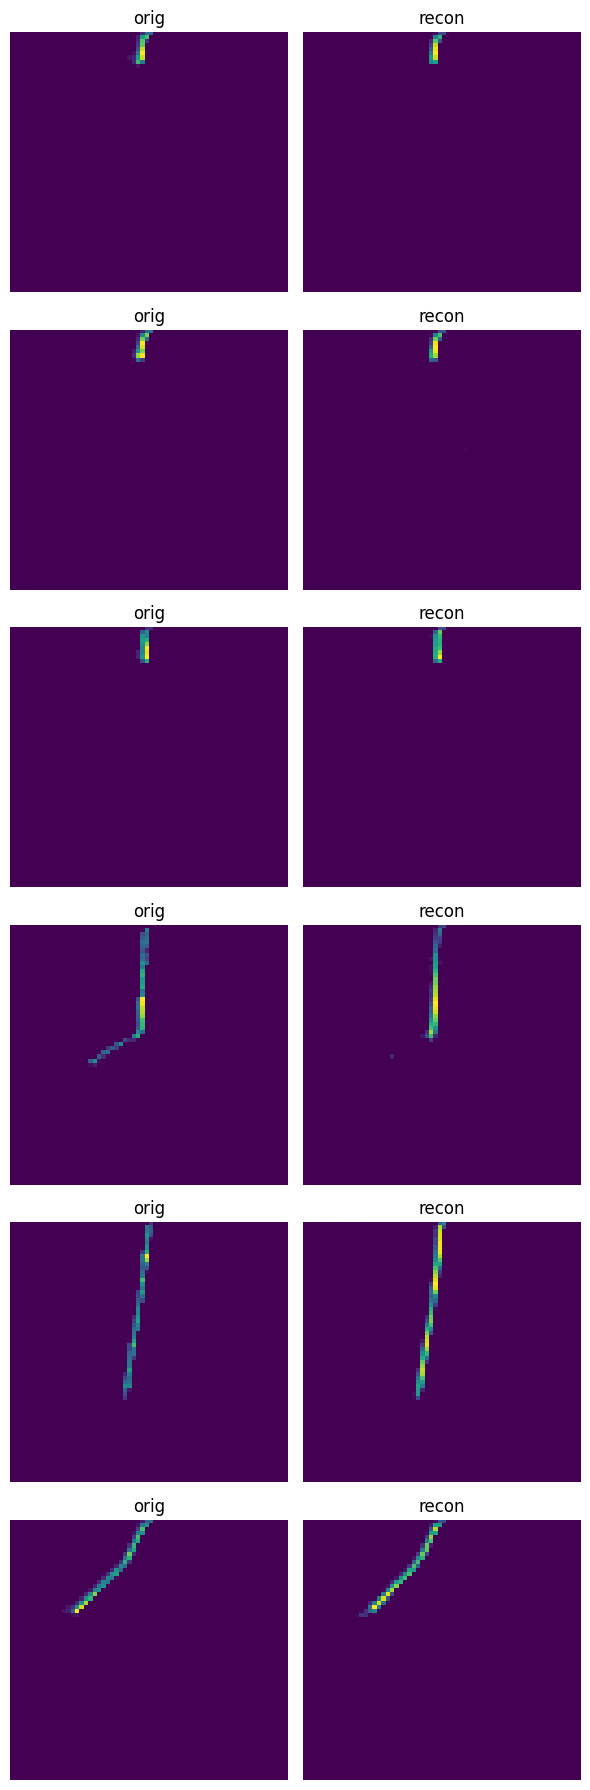

In [458]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d_d.astype(np.float32)          # (N, H, W)
N, H, W = Xd_np.shape
batch_size = 8                           # lower if you get OOM on MPS

recon_all = np.empty((N, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all[i:j] = out.cpu().numpy()

        enc = model.encoder(xb.unsqueeze(1))    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all - Xd_np) ** 2).mean(axis=(1, 2))

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

plt.figure()
plt.hist(RE_per_sample_d, bins=100)
plt.xlim(0, 100)
plt.title("Deuteron RE distribution")
plt.show()

k = min(6, N)
fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
for ii in range(k):
    axs[ii,0].imshow(Xd_np[ii], cmap='viridis', aspect='auto'); axs[ii,0].set_title("orig"); axs[ii,0].axis('off')
    axs[ii,1].imshow(recon_all[ii], cmap='viridis', aspect='auto'); axs[ii,1].set_title("recon"); axs[ii,1].axis('off')
plt.tight_layout()
plt.show()

In [459]:
d_d.shape, RE_per_sample_d.shape

((5115, 64, 64), (5115,))

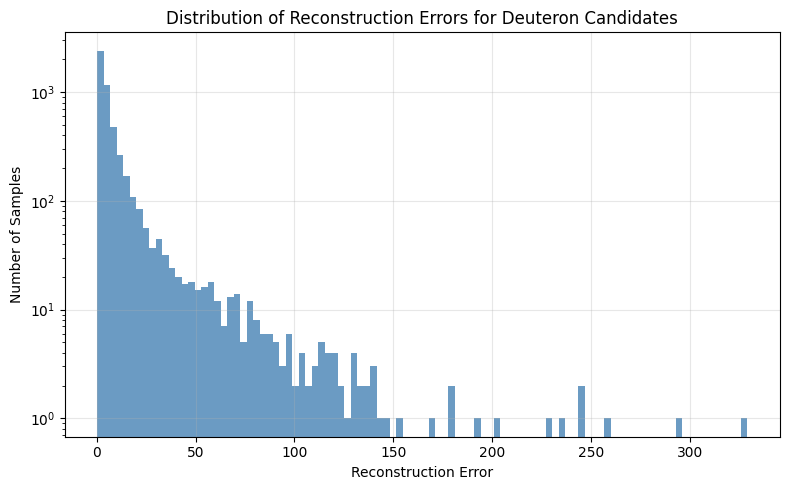

In [460]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_d, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors for Deuteron Candidates")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

164

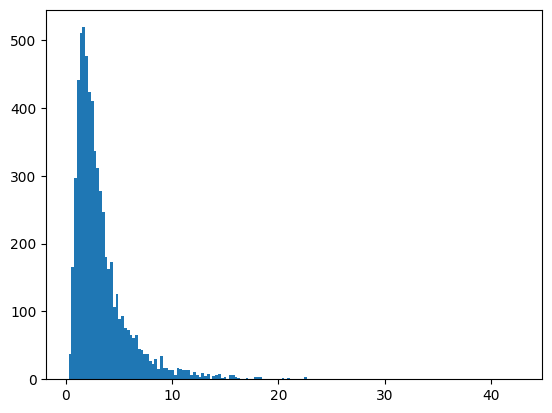

In [465]:

len(plt.hist(RE_per_sample, bins='auto')[1])


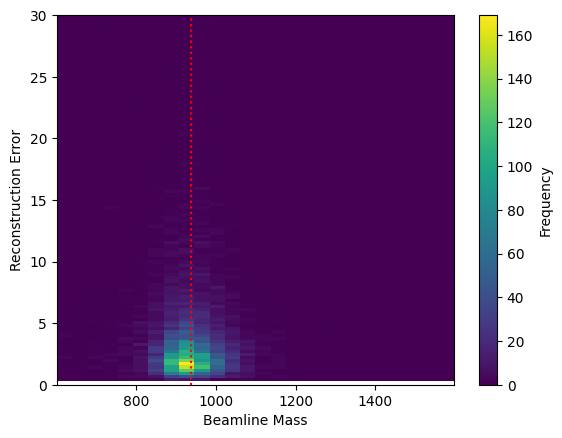

In [482]:
plt.hist2d(protons['beamline_mass'], RE_per_sample, bins=[26, 164]); plt.ylim(0, 30)
plt.colorbar(label='Frequency')
plt.axvline(938.27, linestyle=':', color='r', label=('Proton Mass'))
plt.xlabel('Beamline Mass')
plt.ylabel('Reconstruction Error')
plt.show()

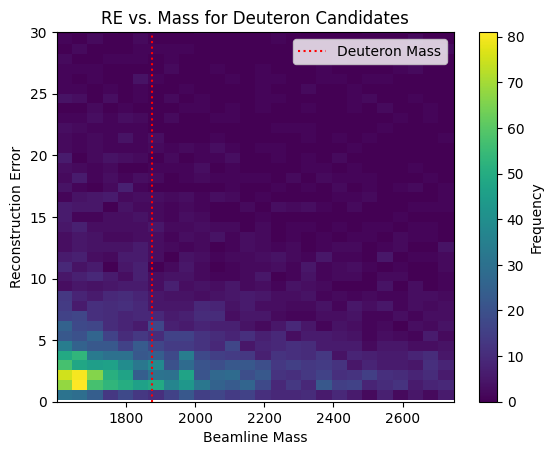

In [479]:
plt.hist2d(deuterons['beamline_mass'], RE_per_sample_d, bins=[26, 410]); plt.ylim(0, 30)
plt.colorbar(label='Frequency')
plt.axvline(1875.6, linestyle=':', color='r', label=('Deuteron Mass'))
plt.xlabel('Beamline Mass')
plt.ylabel('Reconstruction Error')
plt.title('RE vs. Mass for Deuteron Candidates')
plt.legend()
plt.show()

(0.0, 30.0)

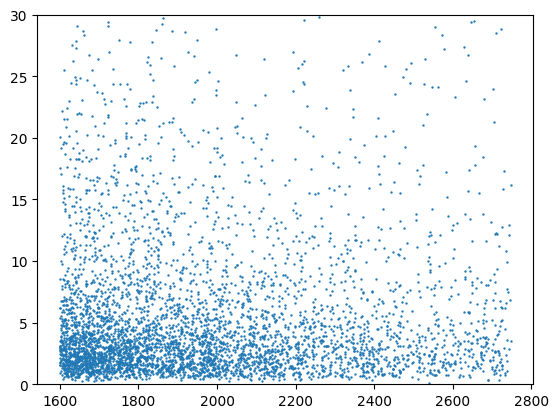

In [483]:
plt.scatter(deuterons['beamline_mass'], RE_per_sample_d, s=0.5); plt.ylim(0, 30)

In [52]:
from sklearn.preprocessing import StandardScaler, normalize

Zs = StandardScaler().fit_transform(latent_vectors)              # Euclidean-friendly
Zc = normalize(latent_vectors, norm='l2')

In [55]:
from sklearn.mixture import GaussianMixture

lowest_bic, best = np.inf, None
for k in range(2, 4):
    for cov in ['full','tied','diag','spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=0)
        gmm.fit(Zs)
        if gmm.bic(Zs) < lowest_bic:
            lowest_bic, best = gmm.bic(Zs), gmm
labels_gmm = best.predict(Zs)
soft = best.predict_proba(Zs)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

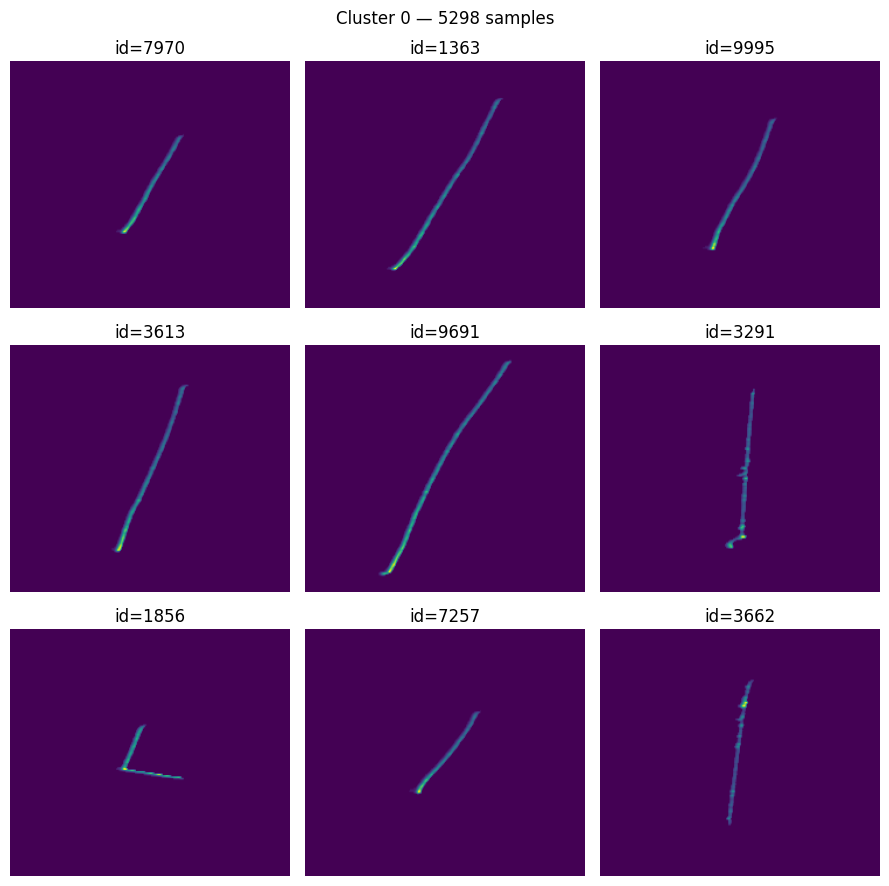

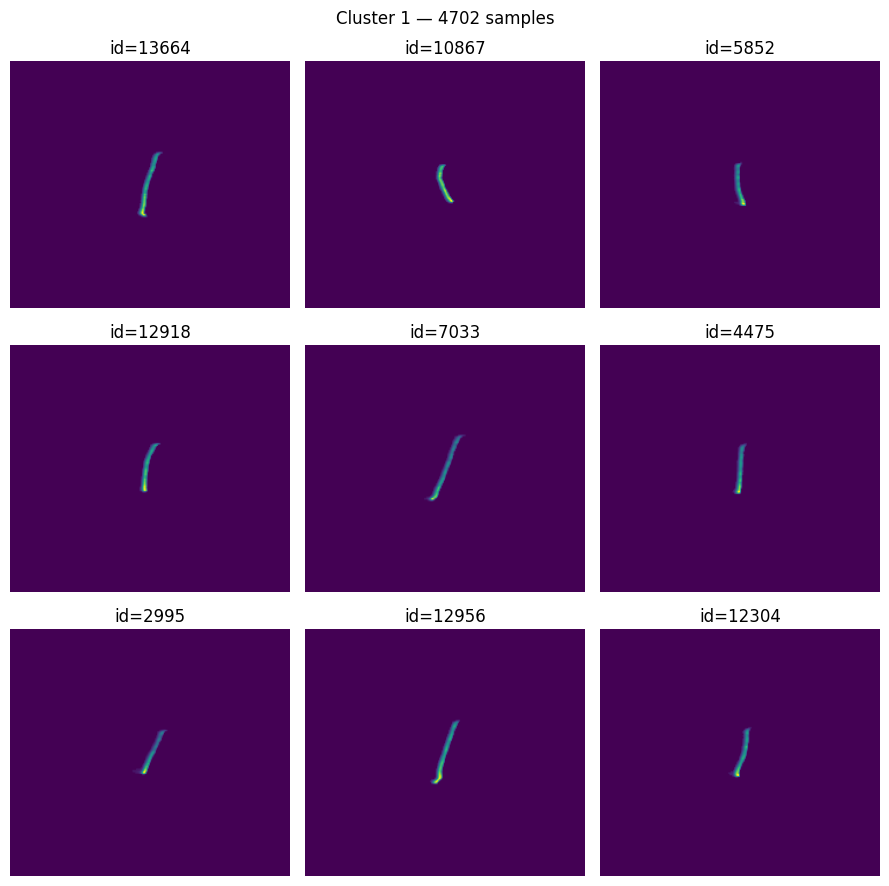

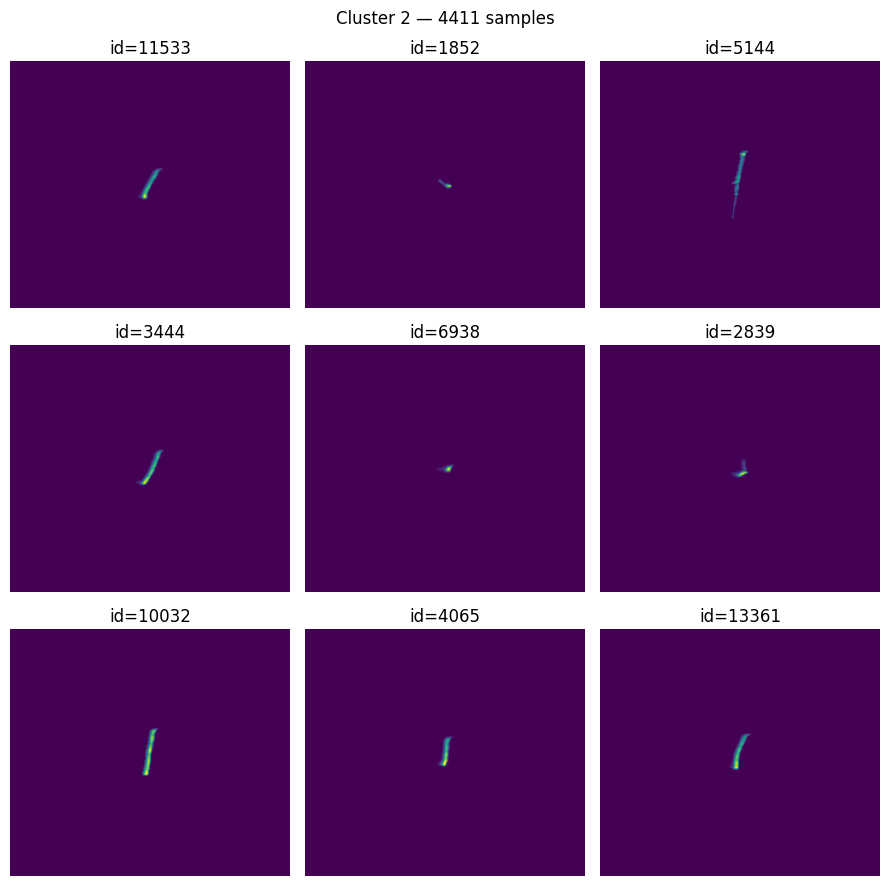

In [56]:
import math
unique_clusters = np.unique(labels_gmm)
for c in unique_clusters:
    idxs = np.where(labels_gmm == c)[0]
    if len(idxs) == 0:
        continue
    n_show = min(9, len(idxs))
    sel = np.random.choice(idxs, n_show, replace=False)
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        if i < n_show:
            ax.imshow(X_np[sel[i]], cmap='viridis', aspect='auto')
            ax.set_title(f"id={sel[i]}")
        ax.axis('off')
    plt.suptitle(f'Cluster {c} — {len(idxs)} samples')
    plt.tight_layout()
    plt.show()

In [57]:
data['cluster_gmm'] = labels_gmm

<Axes: xlabel='maxdiff', ylabel='Count'>

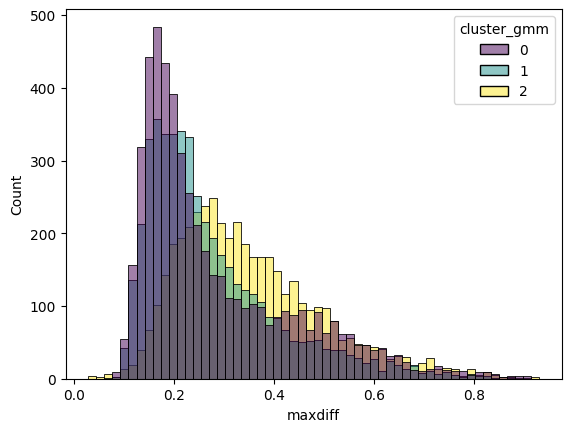

In [60]:
sns.histplot(data=data, x='maxdiff', hue='cluster_gmm', palette='viridis')

(1600.0, 2750.0)

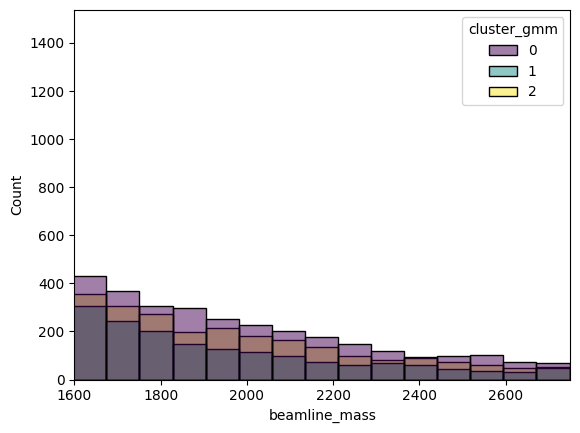

In [73]:
sns.histplot(data=data, x='beamline_mass', hue='cluster_gmm', palette='viridis')
plt.xlim(1600, 2750)